# Logistic Regression with Python

In [55]:
import pandas as pd

from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

import matplotlib.pyplot as plt

# import warnings
# warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix , classification_report

In [2]:
cancer.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [4]:
print(cancer['DESCR'])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [6]:
cancer['feature_names']

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [7]:
cancer['data']

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]])

In [8]:
cancer['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [3]:
df = pd.DataFrame(data = cancer['data'] , columns = cancer['feature_names'])
df[cancer['target_names'][0]] = cancer['target']

In [4]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,malignant
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [5]:
# Class Distribution: 212 - Malignant, 357 - Benign
df['malignant'].value_counts()

malignant
1    357
0    212
Name: count, dtype: int64

In [6]:
df['malignant'].value_counts(normalize = True)

malignant
1    0.627417
0    0.372583
Name: proportion, dtype: float64

In [7]:
df.describe().round(2)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,malignant
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08,0.63
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02,0.48
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06,0.00
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07,0.00
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08,1.00
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09,1.00
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21,1.00


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [9]:
# defining feature (X) and (y) 
X = df.drop('malignant' , axis = 1 )
y = df['malignant']

In [10]:
# splitting X and y into training and testing sets 
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2) 

In [11]:
X_train.shape

(455, 30)

In [12]:
X_train

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
319,12.430,17.00,78.60,477.3,0.07557,0.03454,0.01342,0.01699,0.1472,0.05561,...,12.90,20.21,81.76,515.9,0.08409,0.04712,0.02237,0.02832,0.1901,0.05932
347,14.760,14.74,94.87,668.7,0.08875,0.07780,0.04608,0.03528,0.1521,0.05912,...,17.27,17.93,114.20,880.8,0.12200,0.20090,0.21510,0.12510,0.3109,0.08187
497,12.470,17.31,80.45,480.1,0.08928,0.07630,0.03609,0.02369,0.1526,0.06046,...,14.06,24.34,92.82,607.3,0.12760,0.25060,0.20280,0.10530,0.3035,0.07661
184,15.280,22.41,98.92,710.6,0.09057,0.10520,0.05375,0.03263,0.1727,0.06317,...,17.80,28.03,113.80,973.1,0.13010,0.32990,0.36300,0.12260,0.3175,0.09772
311,14.610,15.69,92.68,664.9,0.07618,0.03515,0.01447,0.01877,0.1632,0.05255,...,16.46,21.75,103.70,840.8,0.10110,0.07087,0.04746,0.05813,0.2530,0.05695
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273,9.742,15.67,61.50,289.9,0.09037,0.04689,0.01103,0.01407,0.2081,0.06312,...,10.75,20.88,68.09,355.2,0.14670,0.09370,0.04043,0.05159,0.2841,0.08175
341,9.606,16.84,61.64,280.5,0.08481,0.09228,0.08422,0.02292,0.2036,0.07125,...,10.75,23.07,71.25,353.6,0.12330,0.34160,0.43410,0.08120,0.2982,0.09825
211,11.840,18.94,75.51,428.0,0.08871,0.06900,0.02669,0.01393,0.1533,0.06057,...,13.30,24.99,85.22,546.3,0.12800,0.18800,0.14710,0.06913,0.2535,0.07993
410,11.360,17.57,72.49,399.8,0.08858,0.05313,0.02783,0.02100,0.1601,0.05913,...,13.05,36.32,85.07,521.3,0.14530,0.16220,0.18110,0.08698,0.2973,0.07745


In [13]:
y_train

319    1
347    1
497    1
184    0
311    1
      ..
273    1
341    1
211    1
410    1
348    1
Name: malignant, Length: 455, dtype: int64

In [14]:
X_test.shape

(114, 30)

In [15]:
# create logistic regression object 
reg = LogisticRegression(max_iter = 10000) 

In [16]:
# train the model using the training sets 
reg.fit(X_train, y_train) 

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [17]:
# making predictions on the testing set 
y_pred = reg.predict(X_test) 

In [18]:
y_pred

array([1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1])

In [19]:
pd.DataFrame({'actual':y_test, 'model_pred':y_pred})

,actual,model_pred
416,1,1
430,0,0
246,1,1
404,1,1
303,1,1
...,...,...
72,0,0
533,0,0
143,1,1
344,1,1


In [20]:
print(confusion_matrix(y_test,y_pred))

[[40  5]
 [ 2 67]]


In [21]:
pd.crosstab(y_test , y_pred)

col_0,0,1
malignant,,
0,40,5
1,2,67


In [25]:
y_test.value_counts()

malignant
1    69
0    45
Name: count, dtype: int64

In [26]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.95      0.89      0.92        45
           1       0.93      0.97      0.95        69

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



In [30]:
#  prob of classes
prob_outcome = pd.DataFrame(reg.predict_proba(X_test), columns = ['prob of class 0', 'prob of class 1']).round(2) 
prob_outcome['model pred'] = y_pred
prob_outcome
# default threshold by predict function is chosen 0.5

,prob of class 0,prob of class 1,model pred
0,0.00,1.00,1
1,0.98,0.02,0
2,0.00,1.00,1
3,0.00,1.00,1
4,0.00,1.00,1
...,...,...,...
109,1.00,0.00,0
110,1.00,0.00,0
111,0.02,0.98,1
112,0.00,1.00,1


In [32]:
prob_outcome['prob of class 1'].values # prob for clss 1

array([1.  , 0.02, 1.  , 1.  , 1.  , 0.8 , 0.46, 0.96, 0.  , 0.  , 0.  ,
       1.  , 1.  , 0.  , 1.  , 0.56, 1.  , 0.82, 0.  , 0.97, 0.92, 0.  ,
       0.  , 0.99, 0.97, 0.97, 1.  , 1.  , 0.  , 1.  , 0.92, 0.  , 0.98,
       1.  , 0.  , 1.  , 0.85, 1.  , 0.89, 0.  , 0.03, 1.  , 1.  , 0.98,
       1.  , 0.93, 1.  , 1.  , 0.  , 0.98, 0.  , 0.  , 0.  , 1.  , 0.  ,
       0.08, 0.65, 0.  , 1.  , 1.  , 0.58, 1.  , 0.02, 0.  , 0.67, 0.98,
       1.  , 1.  , 0.9 , 0.85, 0.9 , 0.01, 1.  , 0.04, 1.  , 0.  , 0.99,
       0.  , 0.  , 0.  , 1.  , 0.28, 1.  , 0.23, 0.86, 0.63, 1.  , 0.  ,
       0.96, 1.  , 0.98, 1.  , 0.97, 0.  , 0.01, 1.  , 0.  , 0.  , 0.96,
       0.  , 0.96, 0.9 , 0.84, 1.  , 1.  , 0.43, 0.11, 0.  , 1.  , 0.  ,
       0.  , 0.98, 1.  , 1.  ])

In [35]:
#  changing thershold
y_pred_custom = [1 if i > 0.8 else 0 for i in prob_outcome['prob of class 1'].values]
# (prob_outcome['prob of class 1'].values > 0.8).astype(int)
y_pred_custom

[1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1]

In [36]:
print(classification_report(y_test , y_pred_custom))

              precision    recall  f1-score   support

           0       0.88      0.93      0.90        45
           1       0.95      0.91      0.93        69

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



### ROC

- It tells your models performance at different thershold values

In [38]:
y_test.values

array([1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1])

In [39]:
prob_outcome['prob of class 1'].values

array([1.  , 0.02, 1.  , 1.  , 1.  , 0.8 , 0.46, 0.96, 0.  , 0.  , 0.  ,
       1.  , 1.  , 0.  , 1.  , 0.56, 1.  , 0.82, 0.  , 0.97, 0.92, 0.  ,
       0.  , 0.99, 0.97, 0.97, 1.  , 1.  , 0.  , 1.  , 0.92, 0.  , 0.98,
       1.  , 0.  , 1.  , 0.85, 1.  , 0.89, 0.  , 0.03, 1.  , 1.  , 0.98,
       1.  , 0.93, 1.  , 1.  , 0.  , 0.98, 0.  , 0.  , 0.  , 1.  , 0.  ,
       0.08, 0.65, 0.  , 1.  , 1.  , 0.58, 1.  , 0.02, 0.  , 0.67, 0.98,
       1.  , 1.  , 0.9 , 0.85, 0.9 , 0.01, 1.  , 0.04, 1.  , 0.  , 0.99,
       0.  , 0.  , 0.  , 1.  , 0.28, 1.  , 0.23, 0.86, 0.63, 1.  , 0.  ,
       0.96, 1.  , 0.98, 1.  , 0.97, 0.  , 0.01, 1.  , 0.  , 0.  , 0.96,
       0.  , 0.96, 0.9 , 0.84, 1.  , 1.  , 0.43, 0.11, 0.  , 1.  , 0.  ,
       0.  , 0.98, 1.  , 1.  ])

In [50]:
import numpy as np

thresholds = np.arange(0 , 1.05 , 0.05).round(2)
thresholds

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

In [59]:
fpr_ = []
tpr = []

for thresh in thresholds:

    y_pred_custom = (prob_outcome['prob of class 1'].values > thresh).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_custom).ravel()

    recall_tpr = tp / (tp + fn)  # y axis
    fpr = fp / (fp + tn) # x axis

    fpr_.append(fpr.round(2))
    tpr.append(recall_tpr.round(2))

Text(0.5, 1.0, 'ROC Curve')

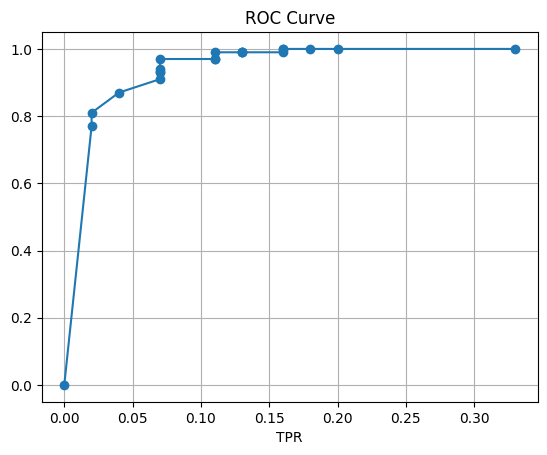

In [64]:
plt.grid(True)
plt.plot(fpr_, tpr, marker = 'o')
plt.xlabel('FPR')
plt.xlabel('TPR')
plt.title('ROC Curve')

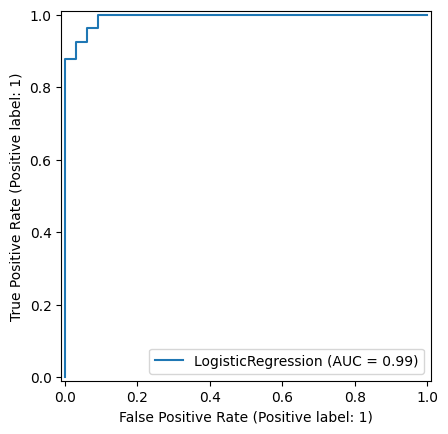

0.9388327721661055


In [22]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score 

log_disp = RocCurveDisplay.from_estimator(reg, X_test, y_test)
plt.show()

print(roc_auc_score(y_test , y_pred))

In [65]:
pd.DataFrame(data = {'cols' : X_train.columns , 'betas' : reg.coef_.flatten()})

,cols,betas
0,mean radius,0.966494
1,mean texture,0.088521
2,mean perimeter,-0.212261
3,mean area,0.022952
4,mean smoothness,-0.167299
5,mean compactness,-0.220129
6,mean concavity,-0.464368
7,mean concave points,-0.264405
8,mean symmetry,-0.184949
9,mean fractal dimension,-0.030926


In [69]:
pd.DataFrame(data = {'cols' : X_train.columns , 'betas' : np.abs(reg.coef_.flatten())}).sort_values('betas')

,cols,betas
19,fractal dimension error,0.006600
23,worst area,0.013172
3,mean area,0.022952
15,compactness error,0.023440
18,symmetry error,0.023725
14,smoothness error,0.029310
9,mean fractal dimension,0.030926
17,concave points error,0.036550
16,concavity error,0.059767
10,radius error,0.072138
